Commands

python -m venv dsEnv
source dsEnv/bin/activate
pip install torch torchvision torchaudio
pip install git+https://github.com/facebookresearch/segment-anything.git
pip install opencv-python pycocotools matplotlib ipykernel
pip install ultralytics

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sprice134/DualSight/blob/master/demo.ipynb)


In [ ]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install torch torchvision torchaudio
    !pip install git+https://github.com/facebookresearch/segment-anything.git
    !pip install opencv-python pycocotools matplotlib ipykernel
    !pip install ultralytics

In [1]:
from segment_anything import SamAutomaticMaskGenerator, sam_model_registry
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.colors as mcolors
import cv2
from torch.utils.data import Dataset
from pathlib import Path
from ultralytics import YOLO
import yaml


In [2]:
def show_anns(anns):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:,:,3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.35]])
        img[m] = color_mask
    ax.imshow(img)

def visualize_sample_with_labels(image, target, save_path):
    """
    Simple visualization of image, bounding boxes, and instance masks.
    """
    # Convert image tensor to [0,1] range for matplotlib
    image = image.permute(1, 2, 0).cpu().numpy()
    image = image - image.min()
    image = image / image.max()

    fig, ax = plt.subplots(1, figsize=(12, 8))
    ax.imshow(image)

    # Draw predicted or GT masks
    masks = target['masks'].cpu().numpy()  # (N, H, W)
    for i, mask in enumerate(masks):
        mask = mask.squeeze()
        mask_color = mcolors.hsv_to_rgb([i / (len(masks)+1), 1, 1]) 
        ax.contour(mask, levels=[0.5], colors=[mask_color], linewidths=2)
        ax.imshow(np.ma.masked_where(mask == 0, mask), alpha=0.4, cmap='hsv')

    # Draw bounding boxes
    boxes = target['boxes'].cpu().numpy()
    for box in boxes:
        xmin, ymin, xmax, ymax = box
        rect = patches.Rectangle(
            (xmin, ymin),
            xmax - xmin, ymax - ymin,
            linewidth=2, edgecolor='red', facecolor='none'
        )
        ax.add_patch(rect)

    plt.axis('off')
    plt.savefig(save_path, bbox_inches='tight')
    plt.close()
    print(f"Visualization saved to {save_path}")

80
dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])


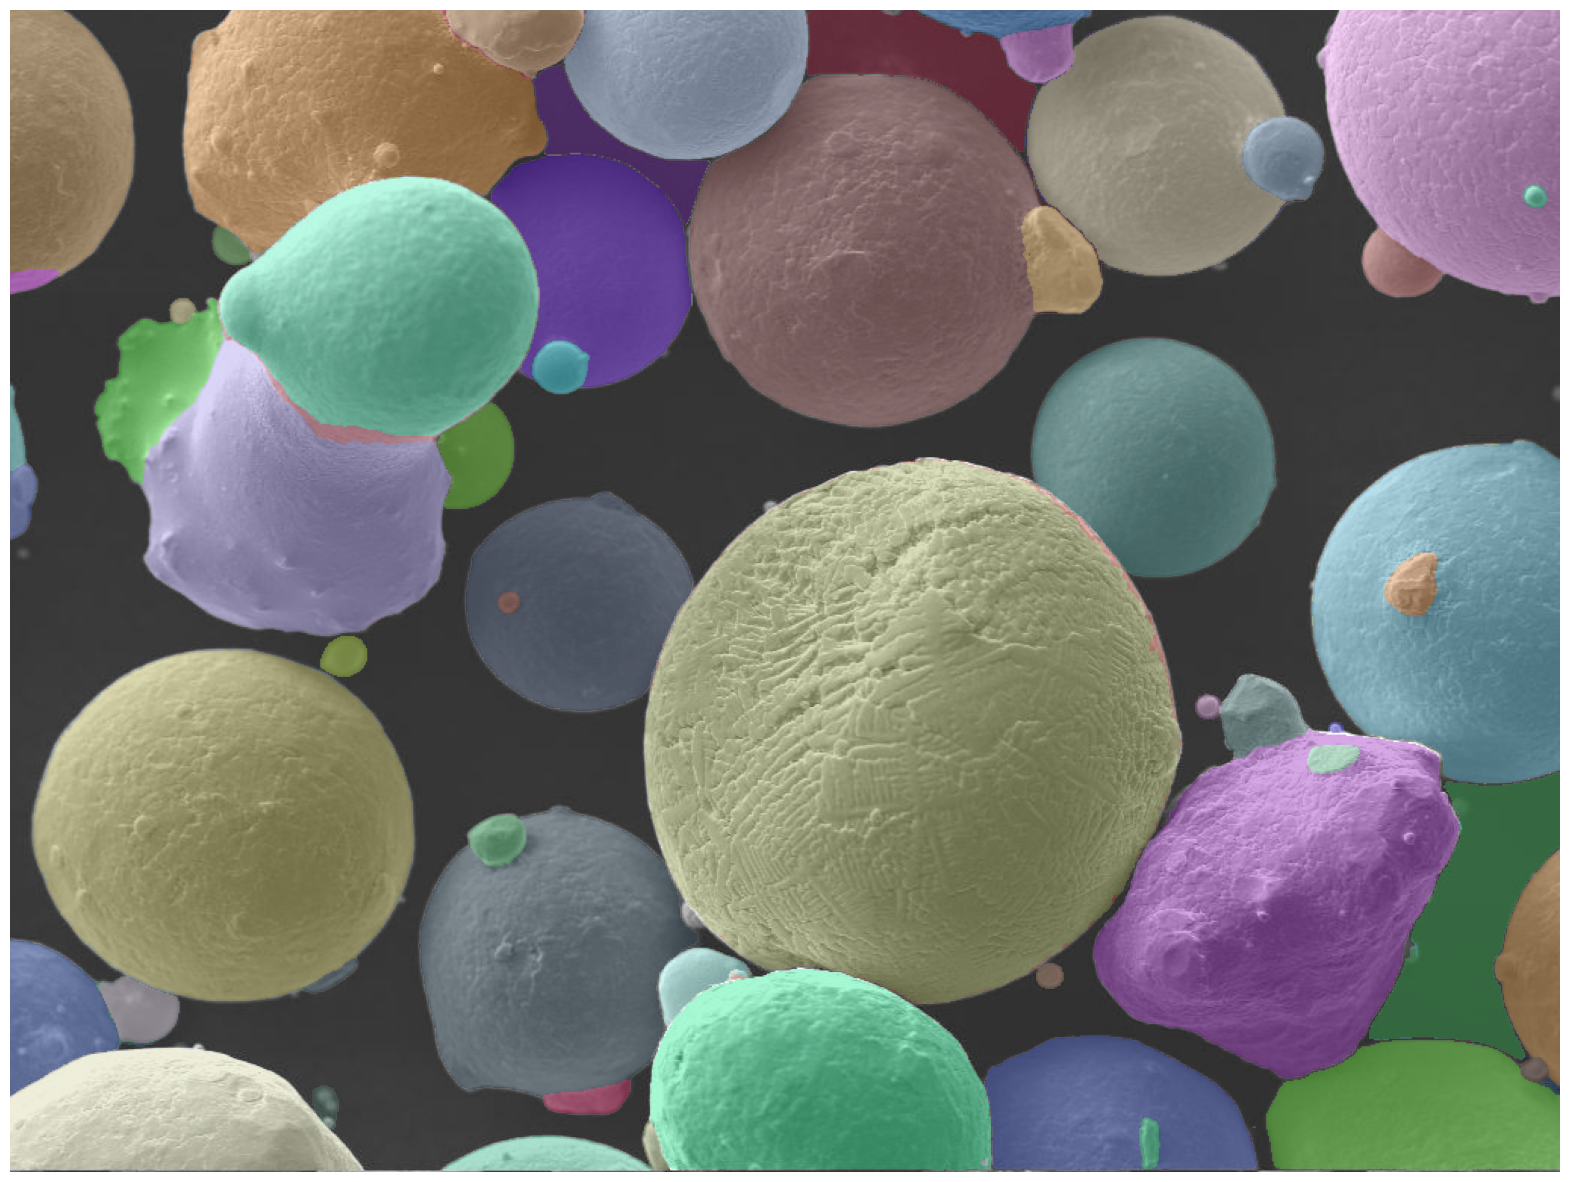

In [3]:
model_type = "vit_l"
checkpoint = "models/sam_vit_l_0b3195.pth"

# Initialize the SAM model using the specified checkpoint
sam = sam_model_registry[model_type](checkpoint=checkpoint)
mask_generator = SamAutomaticMaskGenerator(sam)

# Load the image from the given path
image_path = "demo.v7i.yolov8/test/images/S02_03_SE1_1000X24_png.rf.61ceee7fe0a4f4ccabd61c1e71524baf.jpg"
image = cv2.imread(image_path)

# Generate masks for the image
masks = mask_generator.generate(image)

print(len(masks))
print(masks[0].keys())

plt.figure(figsize=(20,20))
plt.imshow(image)
show_anns(masks)
plt.axis('off')
plt.show() 

In [4]:
def train_yolo(
    data_yaml="../demo.v7i.yolov8/data.yaml",
    epochs=500,
    batch=16,
    device="0",
    model_size="n",
    output_dir='models/'
):
    """
    Trains a YOLOv8 segmentation model. Uses an ultralytics pretrained checkpoint
    (n, s, m, l, xl).
    """

    updated_yaml = update_yaml_paths(data_yaml)

    # Map from short 'model_size' to the ultralytics pretrained segmentation checkpoint
    size_map = {
        "n": "yolov8n-seg.pt",
        "s": "yolov8s-seg.pt",
        "m": "yolov8m-seg.pt",
        "l": "yolov8l-seg.pt",
        "x": "yolov8x-seg.pt",
        "xl": "yolov8x-seg.pt",  # 'x' and 'xl' point to the same file at time of writing
    }

    if YOLO is None:
        raise ImportError("The ultralytics package is not installed. Cannot train YOLO.")
    if model_size not in size_map:
        raise ValueError(f"Unknown model_size '{model_size}'. Choose from n, s, m, l, x, xl.")

    base_checkpoint = size_map[model_size]
    print(f"[YOLO] Using checkpoint: {base_checkpoint}")

    # Load the YOLO model
    model = YOLO(base_checkpoint)

    # Train
    model.train(
        data=updated_yaml,        # path to the data.yaml
        epochs=epochs,
        batch=batch,
        name=f"yolov8{model_size}-seg-train",
        project=output_dir     # This is where the training outputs will be saved
    )


class YoloV8SegmentationDataset(Dataset):
    """
    Example dataset for YOLOv8 polygon-based annotation files (.txt).
    Converts polygons into masks on the fly.
    """
    def __init__(self, image_dir, label_dir, transforms=None, image_size=(1024, 768)):
        self.image_dir = Path(image_dir)
        self.label_dir = Path(label_dir)
        self.transforms = transforms
        self.image_size = image_size

        self.image_files = sorted(list(self.image_dir.glob("*.jpg")))
        self.label_files = sorted(list(self.label_dir.glob("*.txt")))

    def __len__(self):
        return len(self.image_files)

    def _yolo_to_mask(self, label_path, image_size):
        """
        Convert YOLO polygon lines into a single binary mask for segmentation.
        """
        h, w = image_size
        mask = np.zeros((h, w), dtype=np.uint8)
        with open(label_path, "r") as f:
            for line in f:
                elements = line.strip().split()
                cls, *polygon_points = elements
                polygon_points = list(map(float, polygon_points))
                polygon_points = np.array(polygon_points, dtype=np.float32).reshape(-1, 2)

                # Scale up to image size
                polygon_points[:, 0] *= w
                polygon_points[:, 1] *= h
                polygon_points = polygon_points.astype(np.int32)

                # Fill the polygon to create instance regions
                cv2.fillPoly(mask, [polygon_points], color=1)
        return mask

    def __getitem__(self, idx):
        img_path = self.image_files[idx]
        img = Image.open(img_path).convert("RGB")
        img = img.resize(self.image_size)
        w, h = img.size

        label_path = self.label_files[idx]
        mask = self._yolo_to_mask(label_path, (h, w))

        if self.transforms:
            img = self.transforms(img)

        mask = torch.as_tensor(mask, dtype=torch.long)
        return img, mask
    
def update_yaml_paths(yaml_path):
    """
    Loads a YAML file and updates the dataset paths (train, val, test)
    to be absolute paths based on the YAML file's directory.
    Returns the path to a temporary updated YAML file.
    """
    yaml_path = Path(yaml_path)
    base_dir = yaml_path.parent

    # Load the original YAML
    with open(yaml_path, "r") as f:
        data = yaml.safe_load(f)

    # Update paths if they are not absolute
    for key in ['train', 'val', 'test']:
        if key in data:
            path_val = Path(data[key])
            if not path_val.is_absolute():
                # Prepend the base directory
                data[key] = str((base_dir / path_val).resolve())

    # Write updated YAML to a temporary file in the same directory
    temp_yaml_path = base_dir / "data_temp.yaml"
    with open(temp_yaml_path, "w") as f:
        yaml.dump(data, f)

    print(f"Updated YAML saved to: {temp_yaml_path}")
    return str(temp_yaml_path)


In [5]:
train_yolo(
    data_yaml="demo.v7i.yolov8/data.yaml",
    epochs=500,
    batch=16,
    model_size="n",  # or choose s, m, l, x, xl
    output_dir='models/'
)


Updated YAML saved to: demo.v7i.yolov8/data_temp.yaml
[YOLO] Using checkpoint: yolov8n-seg.pt
Ultralytics 8.3.100 🚀 Python-3.12.4 torch-2.6.0 CPU (Apple M3 Pro)
engine/trainer: task=segment, mode=train, model=yolov8n-seg.pt, data=demo.v7i.yolov8/data_temp.yaml, epochs=500, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=models/, name=yolov8n-seg-train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_fram

train: Scanning /Users/sprice/Documents/GitHub/DualSight/demo.v7i.yolov8/train/labels.cache... 79 images, 0 backgrounds, 0 corrupt: 100%|██████████| 79/79 [00:00<?, ?it/s]

train: WARNING ⚠️ /Users/sprice/Documents/GitHub/DualSight/demo.v7i.yolov8/train/images/HP743_6S_250x_png.rf.e4cbc6b4c3230749c1f70115d73e1e0d.jpg: 1 duplicate labels removed
train: WARNING ⚠️ /Users/sprice/Documents/GitHub/DualSight/demo.v7i.yolov8/train/images/Rec-Cu-Ni-Powder_250x_5_SE_V1_png.rf.ee6c20df3dc84def9b43dcf45a7eb105.jpg: 1 duplicate labels removed
train: WARNING ⚠️ /Users/sprice/Documents/GitHub/DualSight/demo.v7i.yolov8/train/images/S02_03_SE1_300X22_png.rf.12f40fb1dc519f7b7f1c3f61e1f18aea.jpg: 3 duplicate labels removed



val: Scanning /Users/sprice/Documents/GitHub/DualSight/demo.v7i.yolov8/valid/labels.cache... 33 images, 0 backgrounds, 0 corrupt: 100%|██████████| 33/33 [00:00<?, ?it/s]

val: WARNING ⚠️ /Users/sprice/Documents/GitHub/DualSight/demo.v7i.yolov8/valid/images/Cu-Ni-Powder_250x_10_SE_V1_png.rf.6573c2d5663824f65896915d61ac31e7.jpg: 1 duplicate labels removed
val: WARNING ⚠️ /Users/sprice/Documents/GitHub/DualSight/demo.v7i.yolov8/valid/images/Cu-Ni-Powder_250x_8_SE_V1_png.rf.abee188aabe10c9a923e27a42e275698.jpg: 2 duplicate labels removed
val: WARNING ⚠️ /Users/sprice/Documents/GitHub/DualSight/demo.v7i.yolov8/valid/images/Rec-Cu-Ni-Powder_250x_2_SE_V1_png.rf.dd883687a9a99dd911d63eab166dac48.jpg: 1 duplicate labels removed
val: WARNING ⚠️ /Users/sprice/Documents/GitHub/DualSight/demo.v7i.yolov8/valid/images/Rec-Cu-Ni-Powder_250x_3_SE_V1_png.rf.7852f9a9c6cb82dffcb490311c3e2a39.jpg: 1 duplicate labels removed
val: WARNING ⚠️ /Users/sprice/Documents/GitHub/DualSight/demo.v7i.yolov8/valid/images/S07_01_SE1_1250X78_png.rf.b53fe6f2604d668c59ebb85db3aad04c.jpg: 1 duplicate labels removed


...


      5/500         0G     0.7418      1.086       1.09      0.937        939        640: 100%|██████████| 5/5 [00:43<00:00,  8.78s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:08<00:00,  4.02s/it]

                   all         33       2133      0.935      0.379      0.721      0.566      0.951      0.385      0.734      0.517



      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss  Instances       Size


  0%|          | 0/5 [00:10<?, ?it/s]


KeyboardInterrupt: 